In [1]:
#Cell 1: Imports & GPU Check
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Check for GPU
device_name = tf.test.gpu_device_name()
if not device_name:
    print('Please activate GPU in Kaggle Settings')
else:
    print(f'Found GPU at: {device_name}')
    

2026-05-07 09:24:23.388783: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778145863.575917      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778145863.634260      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778145864.107859      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778145864.107901      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778145864.107904      23 computation_placer.cc:177] computation placer alr

Found GPU at: /device:GPU:0


I0000 00:00:1778145889.316917      23 gpu_device.cc:2019] Created device /device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778145889.323806      23 gpu_device.cc:2019] Created device /device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [2]:
# Paths for separate train and test folders
train_dir = '/kaggle/input/datasets/shamimulislamsunny/isic-2024-dataset/hair_removed/train'
test_dir = '/kaggle/input/datasets/shamimulislamsunny/isic-2024-dataset/hair_removed/test'

# Parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20  
VAL_SPLIT = 0.2 # 20% for validation from train folder
model_name = "DenseNet121"

class_names = sorted(os.listdir(train_dir))
print(f"Classes: {class_names}")


Classes: ['benign', 'malignant']


In [3]:
#Cell 3: File Extraction (Train & Test)
def get_files_and_labels(path):
    file_paths = []
    labels = []
    for class_idx, class_name in enumerate(class_names):
        class_folder = os.path.join(path, class_name)
        for img_name in os.listdir(class_folder):
            file_paths.append(os.path.join(class_folder, img_name))
            labels.append(class_idx)
    return np.array(file_paths), np.array(labels)

# Load Train and Test file paths separately
train_file_paths, train_labels = get_files_and_labels(train_dir)
test_file_paths, test_labels = get_files_and_labels(test_dir)

print(f"Total Training Images: {len(train_file_paths)}")
print(f"Total Test Images: {len(test_file_paths)}")


Total Training Images: 322498
Total Test Images: 80212


In [4]:
#Cell 4: Training & Validation Split
# Split 20% from train for validation
X_train, X_val, y_train, y_val = train_test_split(
    train_file_paths, train_labels, test_size=VAL_SPLIT, random_state=42, stratify=train_labels
)

print(f"Final Train: {len(X_train)} | Validation: {len(X_val)} | Test: {len(test_file_paths)}")


Final Train: 257998 | Validation: 64500 | Test: 80212


In [5]:
#Cell 5: TensorFlow Data Pipeline
def load_img(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.keras.applications.densenet.preprocess_input(img)
    return img, label

def create_ds(paths, labels, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_img, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(1000)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = create_ds(X_train, y_train, shuffle=True)
val_ds = create_ds(X_val, y_val)
test_ds = create_ds(test_file_paths, test_labels) # Separate test folder data


I0000 00:00:1778145894.476326      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778145894.477744      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [6]:
#Cell 6: DenseNet121 Model Setup
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
base_model.trainable = False 

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x) # Binary classification

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(), tf.keras.metrics.Precision()]
)


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
#Cell 7: Start Training
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "DenseNet121_Final.h5", monitor='val_accuracy', save_best_only=True, mode='max'
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[checkpoint]
)


Epoch 1/20


I0000 00:00:1778145913.990655      69 service.cc:152] XLA service 0x7a188c0036f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778145913.990693      69 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778145913.990697      69 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778145917.370304      69 cuda_dnn.cc:529] Loaded cuDNN version 91002


   1/8063 ━━━━━━━━━━━━━━━━━━━━ 68:46:11 31s/step - accuracy: 0.4375 - loss: 0.9118 - precision: 0.0000e+00 - recall: 0.0000e+00

I0000 00:00:1778145929.413876      69 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


8063/8063 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.9923 - loss: 0.0321 - precision: 0.4100 - recall: 0.1028

...

8063/8063 ━━━━━━━━━━━━━━━━━━━━ 874s 108ms/step - accuracy: 0.9975 - loss: 0.0093 - precision: 0.9343 - recall: 0.6349 - val_accuracy: 0.9973 - val_loss: 0.0096 - val_precision: 0.9071 - val_recall: 0.6209
Epoch 12/20
8062/8063 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9976 - loss: 0.0085 - precision: 0.9207 - recall: 0.6520

8063/8063 ━━━━━━━━━━━━━━━━━━━━ 921s 108ms/step - accuracy: 0.9976 - loss: 0.0085 - precision: 0.9207 - recall: 0.6520 - val_accuracy: 0.9974 - val_loss: 0.0097 - val_precision: 0.8792 - val_recall: 0.6667
Epoch 13/20
8063/8063 ━━━━━━━━━━━━━━━━━━━━ 873s 108ms/step - accuracy: 0.9977 - loss: 0.0080 - precision: 0.9135 - recall: 0.6798 - val_accuracy: 0.9974 - val_loss: 0.0094 - val_precision: 0.9447 - val_recall: 0.6081
Epoch 14/20
8063/8063 ━━━━━━━━━━━━━━━━━━━━ 873s 108ms/step - accuracy: 0.9979 - loss: 0.0078 - precision: 0.9306 - recall: 0.6984 - val_accuracy: 0.9974 - val_loss: 0.0091 - val_precision: 0.9310 - val_recall: 0.6183
Epoch 15/20
8062/8063 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9980 - loss: 0.0074 - precision: 0.9370 - recall: 0.7197

8063/8063 ━━━━━━━━━━━━━━━━━━━━ 873s 108ms/step - accuracy: 0.9980 - loss: 0.0074 - precision: 0.9370 - recall: 0.7197 - val_accuracy: 0.9975 - val_loss: 0.0091 - val_precision: 0.8841 - val_recall: 0.6794
Epoch 16/20
8063/8063 ━━━━━━━━━━━━━━━━━━━━ 872s 108ms/step - accuracy: 0.9979 - loss: 0.0072 - precision: 0.9211 - recall: 0.7115 - val_accuracy: 0.9975 - val_loss: 0.0089 - val_precision: 0.9170 - val_recall: 0.6463
Epoch 17/20
8062/8063 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9980 - loss: 0.0068 - precision: 0.9282 - recall: 0.7214

8063/8063 ━━━━━━━━━━━━━━━━━━━━ 873s 108ms/step - accuracy: 0.9980 - loss: 0.0068 - precision: 0.9282 - recall: 0.7214 - val_accuracy: 0.9976 - val_loss: 0.0087 - val_precision: 0.8727 - val_recall: 0.7150
Epoch 18/20
8063/8063 ━━━━━━━━━━━━━━━━━━━━ 873s 108ms/step - accuracy: 0.9982 - loss: 0.0064 - precision: 0.9384 - recall: 0.7436 - val_accuracy: 0.9976 - val_loss: 0.0088 - val_precision: 0.9020 - val_recall: 0.6794
Epoch 19/20
8062/8063 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9981 - loss: 0.0062 - precision: 0.9323 - recall: 0.7486

8063/8063 ━━━━━━━━━━━━━━━━━━━━ 872s 108ms/step - accuracy: 0.9981 - loss: 0.0062 - precision: 0.9323 - recall: 0.7486 - val_accuracy: 0.9977 - val_loss: 0.0084 - val_precision: 0.9231 - val_recall: 0.6718
Epoch 20/20
8063/8063 ━━━━━━━━━━━━━━━━━━━━ 871s 108ms/step - accuracy: 0.9982 - loss: 0.0058 - precision: 0.9359 - recall: 0.7584 - val_accuracy: 0.9976 - val_loss: 0.0085 - val_precision: 0.9217 - val_recall: 0.6590


Predicting on test data...
2507/2507 ━━━━━━━━━━━━━━━━━━━━ 234s 89ms/step

     CLASSIFICATION REPORT
              precision    recall  f1-score   support

      benign       1.00      1.00      1.00     80133
   malignant       0.20      0.09      0.12        79

    accuracy                           1.00     80212
   macro avg       0.60      0.54      0.56     80212
weighted avg       1.00      1.00      1.00     80212



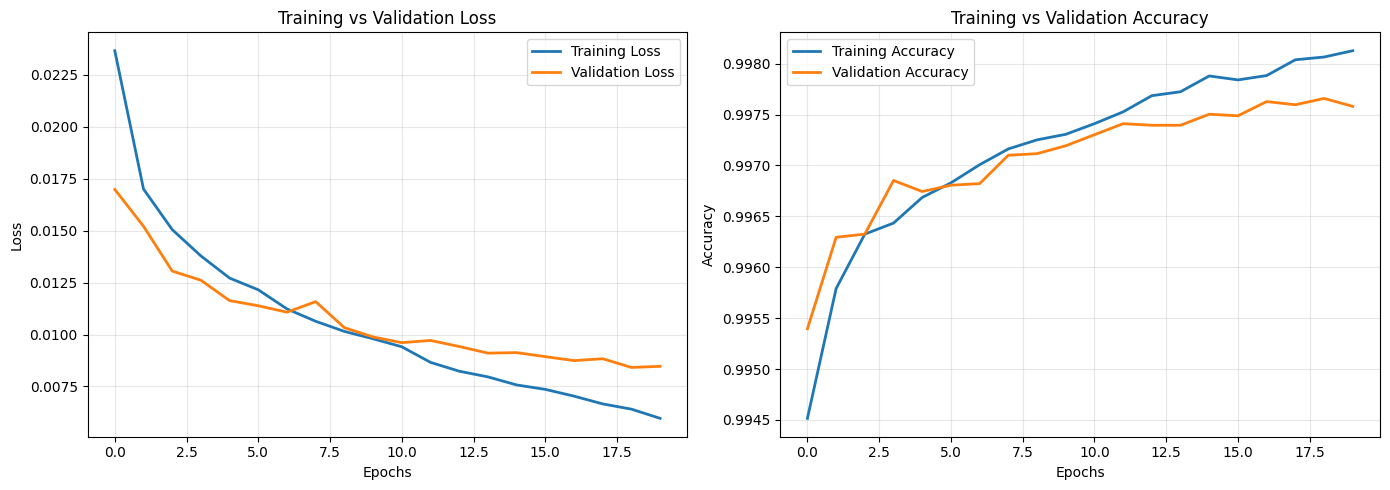

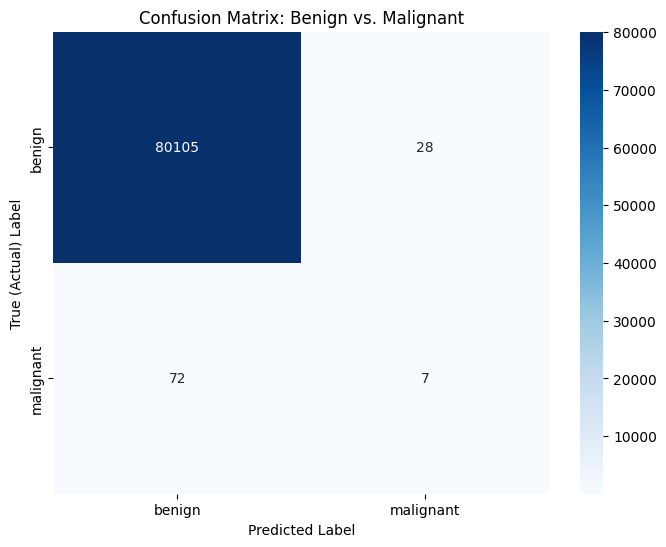

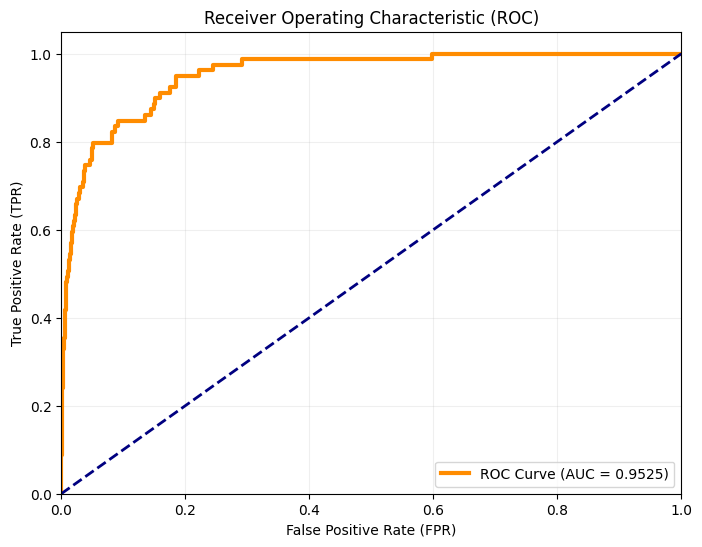


Final Analysis Summary:
Test Set ROC-AUC Score: 0.9525
Best Validation Accuracy Reached: 0.9977


In [8]:
#Cell 8: Performance Evaluation & Visualizations
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# --- 1. PREDICTIONS ---
# Generating probabilities for the test dataset
print("Predicting on test data...")
y_probs = model.predict(test_ds).flatten()
# Using 0.5 threshold to determine binary class (0: Benign, 1: Malignant)
y_pred_classes = (y_probs > 0.5).astype(int)
# Extracting true labels from the test dataset for comparison
y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)

# --- 2. CLASSIFICATION REPORT ---
# This prints Precision, Recall, and F1-Score for both classes
print("\n" + "="*30)
print("     CLASSIFICATION REPORT")
print("="*30)
print(classification_report(y_true, y_pred_classes, target_names=class_names))
print("="*30)

# --- 3. TRAINING HISTORY (LOSS & ACCURACY) ---
history_dict = history.history
plt.figure(figsize=(14, 5))

# Subplot 1: Model Loss
plt.subplot(1, 2, 1)
plt.plot(history_dict['loss'], label='Training Loss', lw=2)
plt.plot(history_dict['val_loss'], label='Validation Loss', lw=2)
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Model Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_dict['accuracy'], label='Training Accuracy', lw=2)
plt.plot(history_dict['val_accuracy'], label='Validation Accuracy', lw=2)
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- 4. CONFUSION MATRIX ---
# Plotting the visual heatmap for easier error analysis
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix: Benign vs. Malignant')
plt.ylabel('True (Actual) Label')
plt.xlabel('Predicted Label')
plt.show()

# --- 5. BINARY ROC CURVE ---
# Calculating False Positive Rate and True Positive Rate
fpr, tpr, _ = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.2)
plt.show()

# --- 6. FINAL SUMMARY ---
print(f"\nFinal Analysis Summary:")
print(f"Test Set ROC-AUC Score: {roc_auc:.4f}")
print(f"Best Validation Accuracy Reached: {max(history_dict['val_accuracy']):.4f}")
